In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt


In [6]:
df = pd.read_csv('personal_finance_expenses.csv', encoding='unicode_escape')


In [7]:
df.head(5)


,date,category,sub_category,amount,payment_mode,is_essential
0,01-07-2025,Shopping,Amazon Purchase,1330,UPI,No
1,01-07-2025,Entertainment,Movies,666,Cash,No
2,01-07-2025,Utilities,Internet Bill,330,Card,Yes
3,02-07-2025,Transport,Auto/Taxi,513,Card,Yes
4,03-07-2025,Shopping,Clothes,659,Card,No


In [8]:
df.info()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 388 entries, 0 to 387
Data columns (total 6 columns):
 #   Column        Non-Null Count  Dtype 
---  ------        --------------  ----- 
 0   date          388 non-null    object
 1   category      388 non-null    object
 2   sub_category  388 non-null    object
 3   amount        388 non-null    int64 
 4   payment_mode  388 non-null    object
 5   is_essential  388 non-null    object
dtypes: int64(1), object(5)
memory usage: 18.3+ KB


In [9]:
df['date'] = pd.to_datetime(df['date'], format='%d-%m-%Y')


In [10]:
df.info()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 388 entries, 0 to 387
Data columns (total 6 columns):
 #   Column        Non-Null Count  Dtype         
---  ------        --------------  -----         
 0   date          388 non-null    datetime64[ns]
 1   category      388 non-null    object        
 2   sub_category  388 non-null    object        
 3   amount        388 non-null    int64         
 4   payment_mode  388 non-null    object        
 5   is_essential  388 non-null    object        
dtypes: datetime64[ns](1), int64(1), object(4)
memory usage: 18.3+ KB


In [11]:
df['year'] = df['date'].dt.year
df['month'] = df['date'].dt.month
df['month_name'] = df['date'].dt.month_name()
df['year_month'] = df['date'].dt.to_period('M')


In [12]:
df[['date', 'month_name', 'year_month']].head()


,date,month_name,year_month
0,2025-07-01,July,2025-07
1,2025-07-01,July,2025-07
2,2025-07-01,July,2025-07
3,2025-07-02,July,2025-07
4,2025-07-03,July,2025-07


In [13]:
df['is_discretionary'] = np.where(df['is_essential'] == 'Yes', 'No', 'Yes')


In [14]:
df['category'].value_counts()
df['payment_mode'].value_counts()
df['is_essential'].value_counts()


is_essential
Yes    204
No     184
Name: count, dtype: int64

In [15]:
df['is_discretionary_flag'] = np.where(df['is_essential'] == 'Yes', 0, 1)


In [17]:
monthly_spend = (
    df
    .groupby('year_month')['amount']
    .sum()
    .reset_index()
)


In [18]:
df.info

<bound method DataFrame.info of           date       category       sub_category  amount payment_mode  \
0   2025-07-01       Shopping    Amazon Purchase    1330          UPI   
1   2025-07-01  Entertainment             Movies     666         Cash   
2   2025-07-01      Utilities      Internet Bill     330         Card   
3   2025-07-02      Transport          Auto/Taxi     513         Card   
4   2025-07-03       Shopping            Clothes     659         Card   
..         ...            ...                ...     ...          ...   
383 2025-10-01            EMI  Personal Loan EMI    4200    AutoDebit   
384 2025-11-01           Rent         House Rent   12000          UPI   
385 2025-11-01            EMI  Personal Loan EMI    4200    AutoDebit   
386 2025-12-01           Rent         House Rent   12000          UPI   
387 2025-12-01            EMI  Personal Loan EMI    4200    AutoDebit   

    is_essential  year  month month_name year_month is_discretionary  \
0             No  2

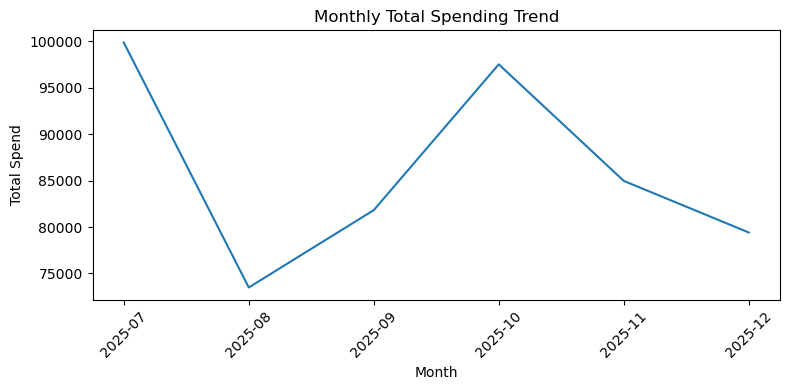

In [19]:
plt.figure(figsize=(8,4))
plt.plot(monthly_spend['year_month'].astype(str), monthly_spend['amount'])
plt.xticks(rotation=45)
plt.title('Monthly Total Spending Trend')
plt.xlabel('Month')
plt.ylabel('Total Spend')
plt.tight_layout()
plt.show()


In [20]:
monthly_category_spend = (
    df
    .groupby(['year_month', 'category'])['amount']
    .sum()
    .reset_index()
)


In [21]:
monthly_category_spend.head(10)


,year_month,category,amount
0,2025-07,EMI,4200
1,2025-07,Entertainment,7711
2,2025-07,Food,3599
3,2025-07,Health,11132
4,2025-07,Rent,12000
5,2025-07,Shopping,26068
6,2025-07,Subscriptions,11214
7,2025-07,Transport,5239
8,2025-07,Utilities,18709
9,2025-08,EMI,4200


In [22]:
category_pivot = monthly_category_spend.pivot(
    index='year_month',
    columns='category',
    values='amount'
).fillna(0)

category_pivot


category,EMI,Entertainment,Food,Health,Rent,Shopping,Subscriptions,Transport,Utilities
year_month,,,,,,,,,
2025-07,4200,7711,3599,11132,12000,26068,11214,5239,18709
2025-08,4200,13745,4398,8638,12000,5827,15955,3840,4889
2025-09,4200,17061,802,2741,12000,18482,13075,1044,12417
2025-10,4200,15874,3474,15891,12000,16816,17507,4829,6938
2025-11,4200,14397,1097,12675,12000,7281,12937,5426,14961
2025-12,4200,13034,4678,4089,12000,13341,5267,5187,17620


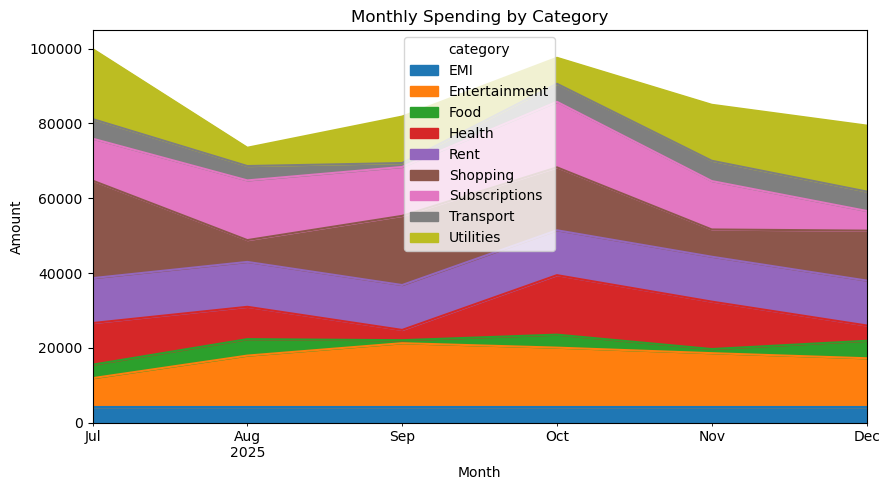

In [23]:
category_pivot.plot(
    kind='area',
    figsize=(9,5),
    title='Monthly Spending by Category'
)
plt.xlabel('Month')
plt.ylabel('Amount')
plt.tight_layout()
plt.show()


In [24]:
essential_split = (
    df
    .groupby(['year_month', 'is_essential'])['amount']
    .sum()
    .reset_index()
)

essential_split


,year_month,is_essential,amount
0,2025-07,No,44993
1,2025-07,Yes,54879
2,2025-08,No,35527
3,2025-08,Yes,37965
4,2025-09,No,48618
5,2025-09,Yes,33204
6,2025-10,No,50197
7,2025-10,Yes,47332
8,2025-11,No,34615
9,2025-11,Yes,50359


In [25]:
essential_pivot = essential_split.pivot(
    index='year_month',
    columns='is_essential',
    values='amount'
).fillna(0)

essential_pivot


is_essential,No,Yes
year_month,,
2025-07,44993,54879
2025-08,35527,37965
2025-09,48618,33204
2025-10,50197,47332
2025-11,34615,50359
2025-12,31642,47774


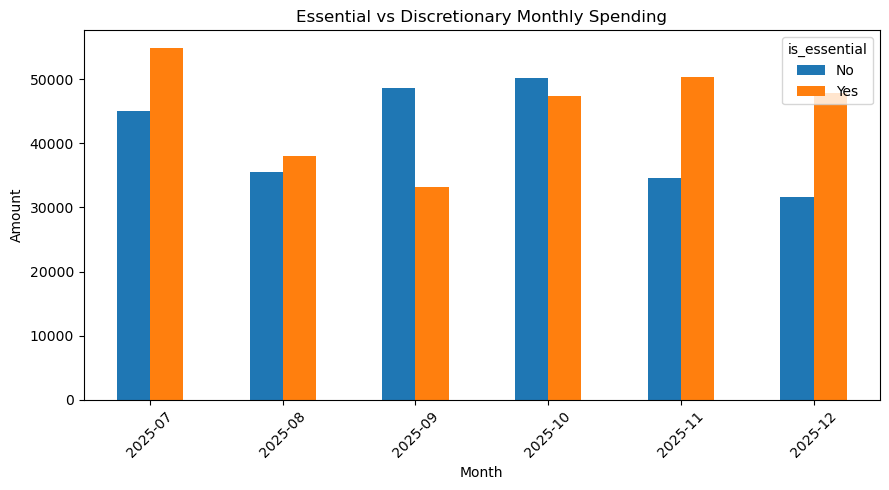

In [26]:
essential_pivot.plot(
    kind='bar',
    figsize=(9,5),
    title='Essential vs Discretionary Monthly Spending'
)

plt.xlabel('Month')
plt.ylabel('Amount')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()


In [28]:
monthly_stats = monthly_spend.copy()
mean_spend = monthly_stats['amount'].mean()
std_spend = monthly_stats['amount'].std()

mean_spend, std_spend


(np.float64(86184.16666666667), 10425.489924539117)

In [29]:
monthly_stats['is_anomaly'] = monthly_stats['amount'] > (mean_spend + 1.5 * std_spend)
monthly_stats


,year_month,amount,is_anomaly
0,2025-07,99872,False
1,2025-08,73492,False
2,2025-09,81822,False
3,2025-10,97529,False
4,2025-11,84974,False
5,2025-12,79416,False


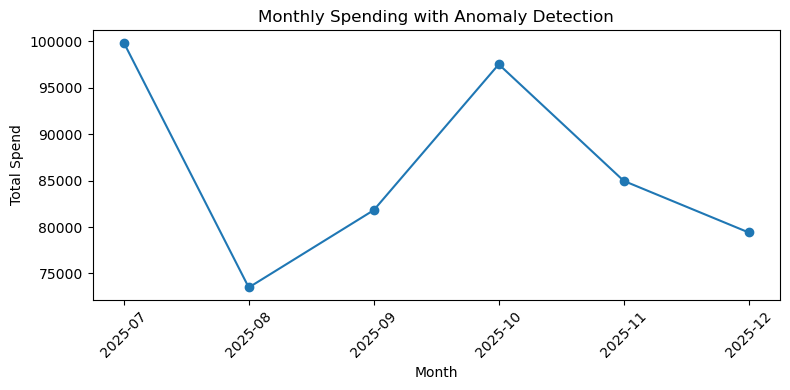

In [30]:
plt.figure(figsize=(8,4))
plt.plot(monthly_stats['year_month'].astype(str), monthly_stats['amount'], marker='o')

for i, row in monthly_stats.iterrows():
    if row['is_anomaly']:
        plt.scatter(str(row['year_month']), row['amount'], s=100)

plt.title('Monthly Spending with Anomaly Detection')
plt.xlabel('Month')
plt.ylabel('Total Spend')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()


In [ ]:
# - Set discretionary spending caps during high-risk months
# - Monitor rolling 30-day spend to detect early overspend signals
# - Prioritize fixed cost stability before discretionary expansion


In [32]:
monthly_stats['is_anomaly'] = monthly_stats['amount'] > (mean_spend + 1.0 * std_spend)
monthly_stats


,year_month,amount,is_anomaly
0,2025-07,99872,True
1,2025-08,73492,False
2,2025-09,81822,False
3,2025-10,97529,True
4,2025-11,84974,False
5,2025-12,79416,False


In [35]:
# A tighter threshold was used due to limited sample size and low variance typical of personal finance data.

In [34]:
p90 = monthly_stats['amount'].quantile(0.90)

monthly_stats['is_anomaly'] = monthly_stats['amount'] > p90
monthly_stats


,year_month,amount,is_anomaly
0,2025-07,99872,True
1,2025-08,73492,False
2,2025-09,81822,False
3,2025-10,97529,False
4,2025-11,84974,False
5,2025-12,79416,False


In [ ]:
# Months above the 90th percentile are treated as anomalous high-spend periods.